# Práctica 8

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from statistics import mode
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, precision_score, f1_score, roc_curve, roc_auc_score

Descargue el conjunto de datos [titanic.csv](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) y lea la [descripción](https://www.kaggle.com/competitions/titanic/data) del mismo. Este conjunto de datos será usado en los siguientes puntos, los cuales deben ser resueltos usando Pandas y TensorFlow.

## 1. Prepare los datos.

### a. Cargue los datos usando Pandas.

In [2]:
!wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv -O titanic.csv

--2025-06-22 01:46:04--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv’

titanic.csv         100%[===================>]  58.89K  --.-KB/s    in 0.007s  

2025-06-22 01:46:04 (8.17 MB/s) - ‘titanic.csv’ saved [60302/60302]



In [3]:
df = pd.read_csv('titanic.csv').set_index('PassengerId')
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### b. Selecciones las siguientes características del dataset: Survived, Pclass, Sex, Age, SibSp, Parch, Fare, Embarked.

In [4]:
df = df[['Survived', 'Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S


### c. Imprima las primeras filas del dataframe es inspeccione los datos. Qué variables son categóricas y cuáles son numéricas?


In [5]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.6+ KB


### d. Verifique cuántos datos faltantes hay usando las funciones isnull and sum de Pandas

In [7]:
null = df.isnull().sum()
null

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


### e. Utilice la función fillna de Pandas para manejar valores faltantes, use la mediana o la moda según aplique.

In [8]:
df_clean = df.fillna({
    'Age': df['Age'].median(),
    'Embarked': df['Embarked'].mode()[0]
})
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.6+ KB


### f. Convierta las columnas con valores categóricos a valores numéricos usando la función get dummies de Pandas.

In [9]:
df_clean_num = pd.get_dummies(df_clean, columns=['Sex', 'Embarked']).astype(int)
df_clean_num.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
1,0,3,22,1,0,7,0,1,0,0,1
2,1,1,38,1,0,71,1,0,1,0,0
3,1,3,26,0,0,7,1,0,0,0,1
4,1,1,35,1,0,53,1,0,0,0,1
5,0,3,35,0,0,8,0,1,0,0,1


### g. Cree dos arreglos de numpy, X y y, para los datos de entrada y la variable de clase (Survived)


In [10]:
X = df_clean_num.drop('Survived', axis=1).values
y = df_clean_num['Survived'].values

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (891, 10)
y shape: (891,)


## 2. Entrene un modelo de clasificación basado en redes neuronales.


### a. Haga una partición del conjunto de datos, usando muestreo estratificado, en 60% para entrenamiento, 20 % de validación y 20 % para test.

In [11]:
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

print('X_train shape:', X_train.shape)
print('X_val shape:', X_val.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_val shape:', y_val.shape)
print('y_test shape:', y_test.shape)

X_train shape: (712, 10)
X_val shape: (89, 10)
X_test shape: (90, 10)
y_train shape: (712,)
y_val shape: (89,)
y_test shape: (90,)


### b. Defina un modelo en Keras que tenga tantas entradas como columnas en X, una capa oculta con 10 neuronas y función de activación sigmoide y una neurona de salida con función de activación sigmoide. Imprima un resumen de la arquitectura del modelo. ¿Cuántos parámetros tiene?


In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation='sigmoid'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

### c. Compile el modelo especificando un optimizador Adam y una pérdida Binary Cross Entropy.

In [13]:
def build_model(lr):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(10, activation='sigmoid'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy'
    )
    return model

### d.  Entrene el modelo usando diferentes valores de la tasa de aprendizaje (learning rate): $10^0 , 10^{-1}, 10^{-2}, 10^{-3}, 10^{-4},$ etc. Use 30 epochs. Grafique curvas de aprendizaje de la pérdida de entrenamiento y la pérdida en validación. Que tasa de aprendizaje es mejor? Explique.

In [14]:
lrs = [float(10**-i) for i in range(6)]

histories = [None] * len(lrs)
models = [None] * len(lrs)
for i, lr in enumerate(lrs):
    print(f'Training model with learning rate: {lr}')
    models[i] = build_model(lr)
    histories[i] = models[i].fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        verbose=0
    )

Training model with learning rate: 1.0
Training model with learning rate: 0.1
Training model with learning rate: 0.01
Training model with learning rate: 0.001
Training model with learning rate: 0.0001
Training model with learning rate: 1e-05


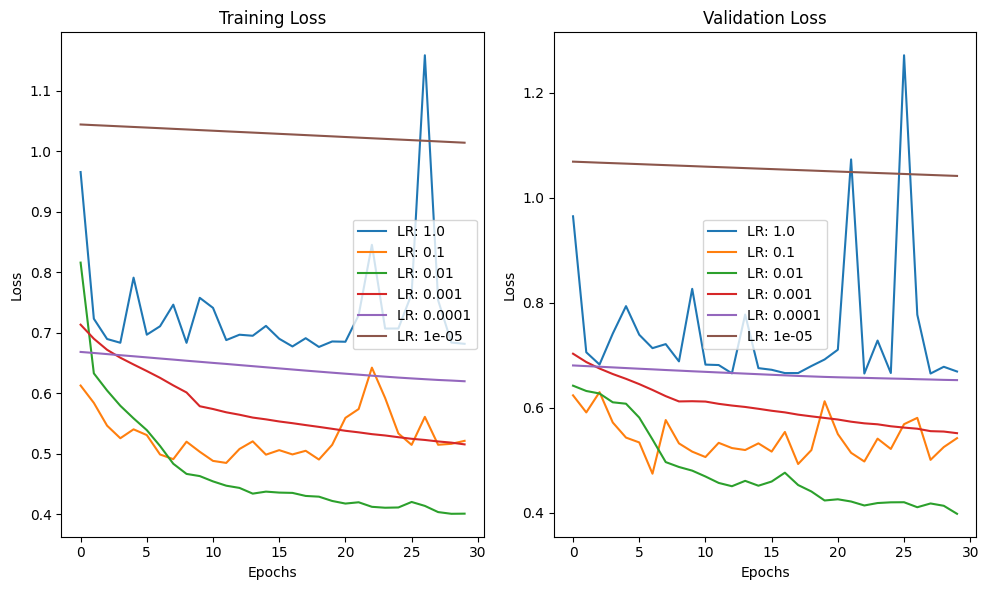

In [15]:
plt.figure(figsize=(10, 6))
for i, history in enumerate(histories):
    plt.subplot(1,2, 1)
    plt.plot(history.history['loss'], label=f'LR: {lrs[i]}')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1,2, 2)
    plt.plot(history.history['val_loss'], label=f'LR: {lrs[i]}')
    plt.title('Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()

Es evidente que con el primer valor, la tasa de aprendizaje es tan grande que el algoritmo no logra converger a un mínimo local asociado a la pérdida. dado esto, se plantea graficar de nuevo estas curvas sin incluir este escenario

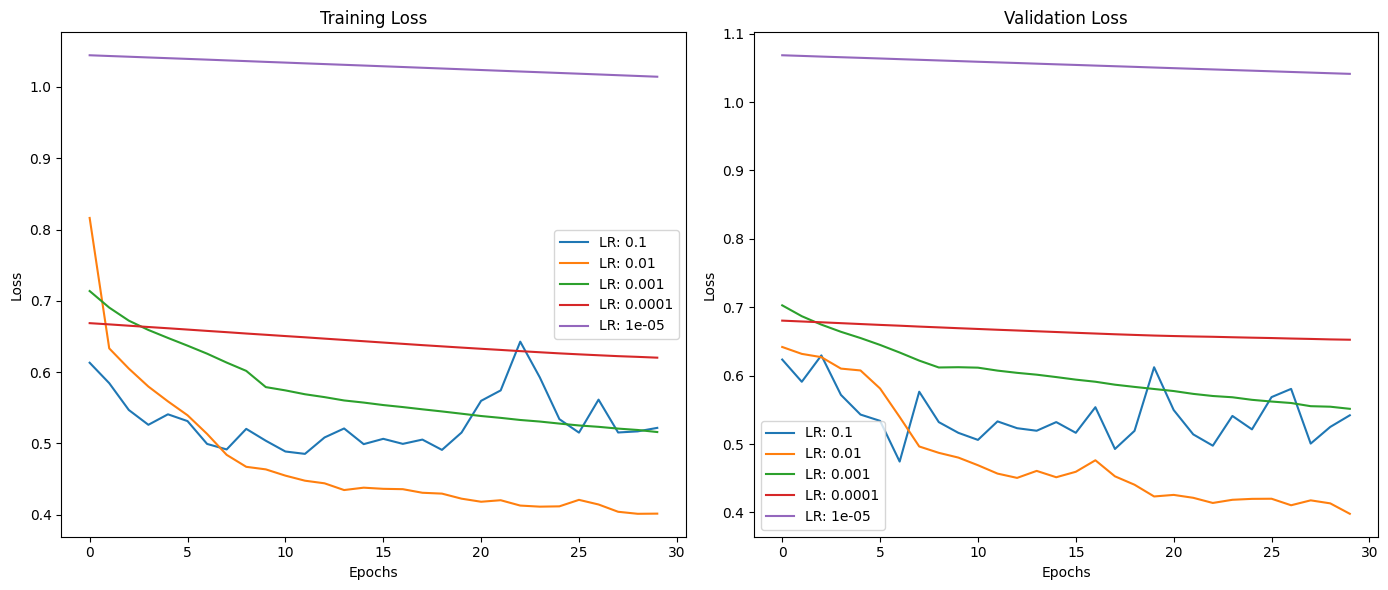

In [16]:
from_ =  1

plt.figure(figsize=(14, 6))

for i, history in enumerate(histories[from_:]):
    plt.subplot(1,2, 1)
    plt.plot(history.history['loss'], label=f'LR: {lrs[i+from_]}')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1,2, 2)
    plt.plot(history.history['val_loss'] , label=f'LR: {lrs[i+from_]}')
    plt.title('Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()

Con esta información, es evidente que utilizar una tasa de aprendizaje de $0.01$ se logra converger a un mínimo local en menos épocas, a diferencia de lo que se ve con los demás valores. Dado que este valor permite obtener ese punto medio entre alcanzar la convergencia y reducir la pérdida de manera rápida, podemos considerar este valor como el mejor de los explorados

### e. Aplique el mejor modelo al conjunto de test.

In [17]:
index = np.argmin([history.history['val_loss'][-1] for history in histories])
print(f'Minimum validation loss at index: {index}, learning rate: {lrs[index]}')

best_model = models[index]
r = best_model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {r}')
y_pred_probs = best_model.predict(X_test).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

Minimum validation loss at index: 2, learning rate: 0.01
Test loss: 0.49339285492897034
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


### f. Mida el desempeño del modelo calculando exactitud, error de clasificación, precisión, recall, curva ROC y matriz de confusión.

In [18]:
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fpr, tpr, thresholds  = roc_curve(y_test, y_pred_probs)
auc = roc_auc_score(y_test, y_pred_probs,)
cmp = confusion_matrix(y_test, y_pred)

In [19]:
print(f'Accuracy: {acc:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Precision: {precision:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'AUC: {auc:.4f}')

Accuracy: 0.7778
Recall: 0.6286
Precision: 0.7586
F1 Score: 0.6875
AUC: 0.8249


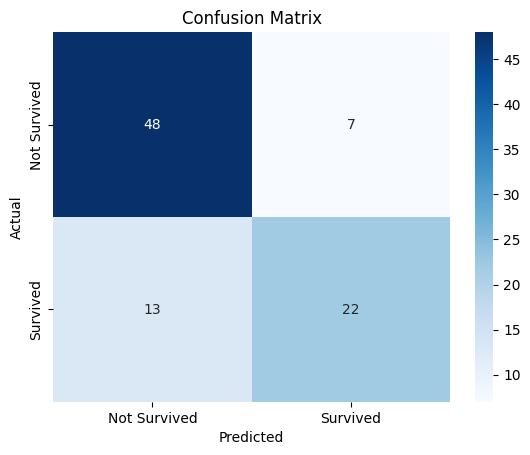

In [20]:
sns.heatmap(cmp, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

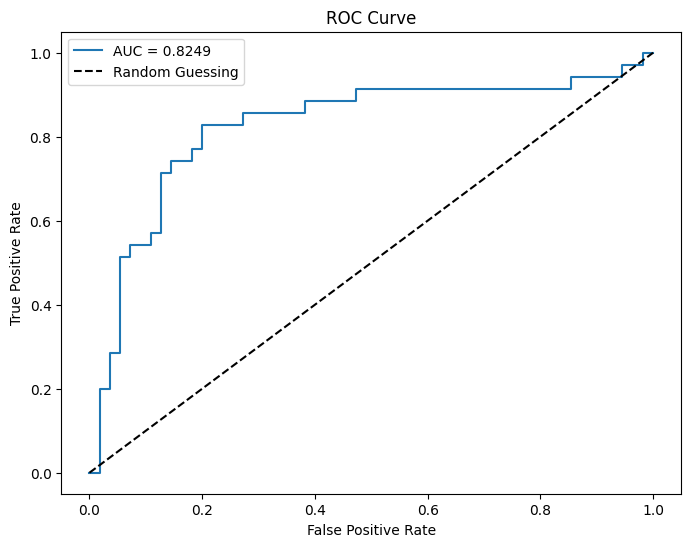

In [21]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Con esto podemos ver que el modelo tiene mejor desempeño para predecir cuando las personas no sobrevivieron al accidente; mientras que le cuesta más identificar cuando sobrevivieron. Esto es evidente en la matriz de confusión, al tener un mayor de falsos negativos y una baja cantidad de verdaderos positivos.

Esto puede ser resultado del desbalanceo de los datos (No es secreto para nadie que fue mayor la cantidad de personas que fallecieron en el siniestro que las que sobrevivieron)

## 3. Exploración de hiperparámetros.

### a. Varíe el número de neuronas en la capa oculta de 2 a 20. Determine cuál es la mejor configuración. Explique.

In [22]:
def build_model(lr=0.01,num_neurons=10):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(num_neurons, activation='sigmoid'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy'
    )
    return model

In [23]:
num_neurons_list = [i for i in range(2, 21)]
histories_neurons = [None] * len(num_neurons_list)
models_neurons = [None] * len(num_neurons_list)

for i, num_neurons in enumerate(num_neurons_list):
    print(f'Training model with {num_neurons} neurons')
    models_neurons[i] = build_model(num_neurons=num_neurons)
    histories_neurons[i] = models_neurons[i].fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=0
    )

Training model with 2 neurons
Training model with 3 neurons
Training model with 4 neurons
Training model with 5 neurons
Training model with 6 neurons
Training model with 7 neurons
Training model with 8 neurons
Training model with 9 neurons
Training model with 10 neurons
Training model with 11 neurons
Training model with 12 neurons
Training model with 13 neurons
Training model with 14 neurons
Training model with 15 neurons
Training model with 16 neurons
Training model with 17 neurons
Training model with 18 neurons
Training model with 19 neurons
Training model with 20 neurons


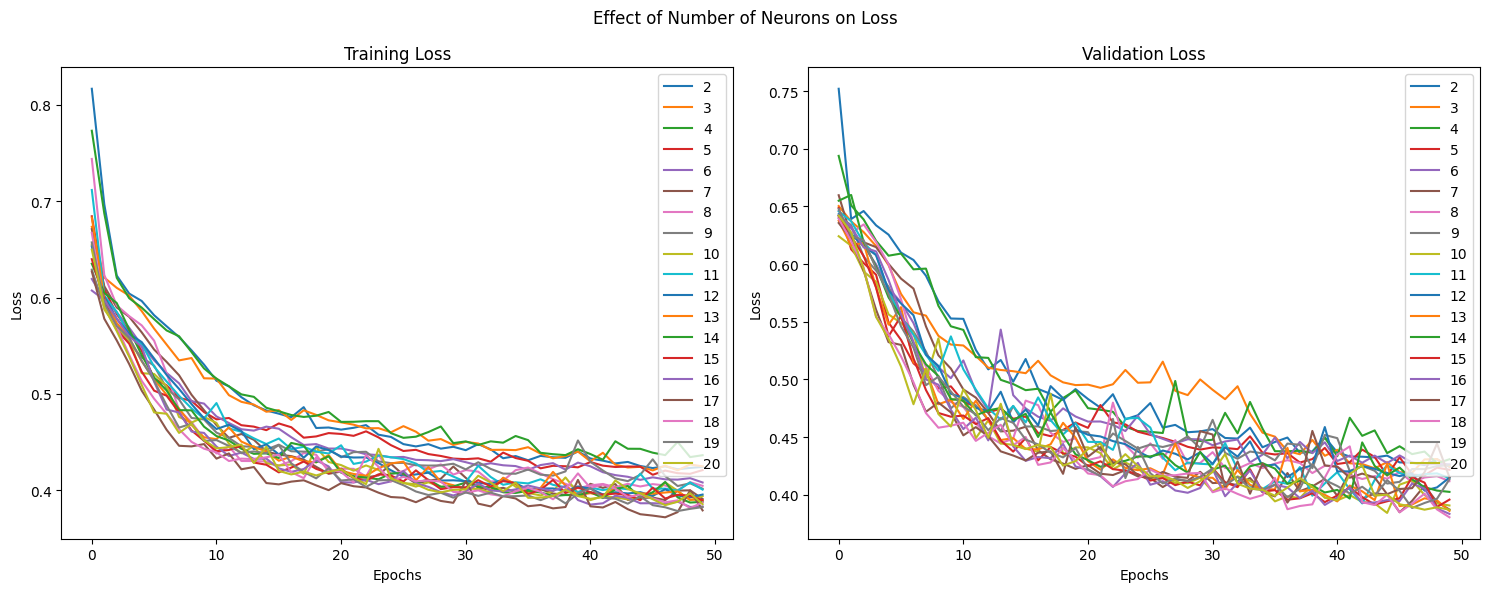

In [24]:
from_ =  0

plt.figure(figsize=(15, 6))

for i, history in enumerate(histories_neurons[from_:]):
    plt.subplot(1,2, 1)
    plt.plot(history.history['loss'], label=f'{num_neurons_list[i+from_]}')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1,2, 2)
    plt.plot(history.history['val_loss'] , label=f'{num_neurons_list[i+from_]}')
    plt.title('Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
plt.suptitle('Effect of Number of Neurons on Loss')
plt.tight_layout()
plt.show()

En este escenario, las curvas no nos muestran un escenario muy claro (Todas tienen tendencia a converger) por lo que trataremos de ver como cambian las métricas de desempeño para ver que modelo da un mejor resultado.

In [25]:
data = {}
for i, model in enumerate(models_neurons):
    y_pred_probs = model.predict(X_test, verbose = 0).flatten()
    y_pred = (y_pred_probs > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_probs)
    data[num_neurons_list[i]] = {
        'accuracy': acc,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'auc': auc
    }
df_metrics = pd.DataFrame(data).T
df_metrics = df_metrics.sort_index()
df_metrics

,accuracy,recall,precision,f1,auc
2,0.788889,0.657143,0.766667,0.707692,0.829610
3,0.766667,0.571429,0.769231,0.655738,0.804156
4,0.755556,0.485714,0.809524,0.607143,0.803117
5,0.800000,0.628571,0.814815,0.709677,0.818701
6,0.777778,0.714286,0.714286,0.714286,0.818182
7,0.800000,0.657143,0.793103,0.718750,0.829091
8,0.788889,0.600000,0.807692,0.688525,0.826494
9,0.777778,0.542857,0.826087,0.655172,0.810390
10,0.811111,0.657143,0.821429,0.730159,0.841039
11,0.822222,0.714286,0.806452,0.757576,0.814545


In [26]:
metrics = df_metrics.columns
model_indexes = df_metrics.values.argmax(axis=0) + 2
for metric, best_metric_model in zip(metrics, model_indexes):
    print(f'Best {metric} at {best_metric_model} neurons: {df_metrics[metric].max():.4f}')

Best accuracy at 11 neurons: 0.8222
Best recall at 6 neurons: 0.7143
Best precision at 9 neurons: 0.8261
Best f1 at 11 neurons: 0.7576
Best auc at 15 neurons: 0.8457


Con este nuevo escenario, es posible ver que en un modelo con 11 neuronas es posible tener un resultado mas robusto respecto a las metricas de Accuracy y F1_score

### b.  Pruebe diferentes funciones de activación para la capa oculta. Muestre y discuta los resultados.

Para este escenario, tomaremos un modelo con 14 neuronas y probaremos la activación sigmoide, relu, tanh, lineal y leaky_relu

In [27]:
def build_model(lr=0.01,num_neurons=14,activation='sigmoid'):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(num_neurons, activation=activation),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy'
    )
    return model

In [28]:
activations = ['sigmoid', 'relu', 'tanh', 'linear', 'leaky_relu']

histories_activations = [None] * len(activations)
models_activations = [None] * len(activations)

for i, activation in enumerate(activations):
    print(f'Training model with activation {activation}')
    models_activations[i] = build_model(activation=activation)
    histories_activations[i] = models_neurons[i].fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=32,
        verbose=0
    )

Training model with activation sigmoid
Training model with activation relu
Training model with activation tanh
Training model with activation linear
Training model with activation leaky_relu


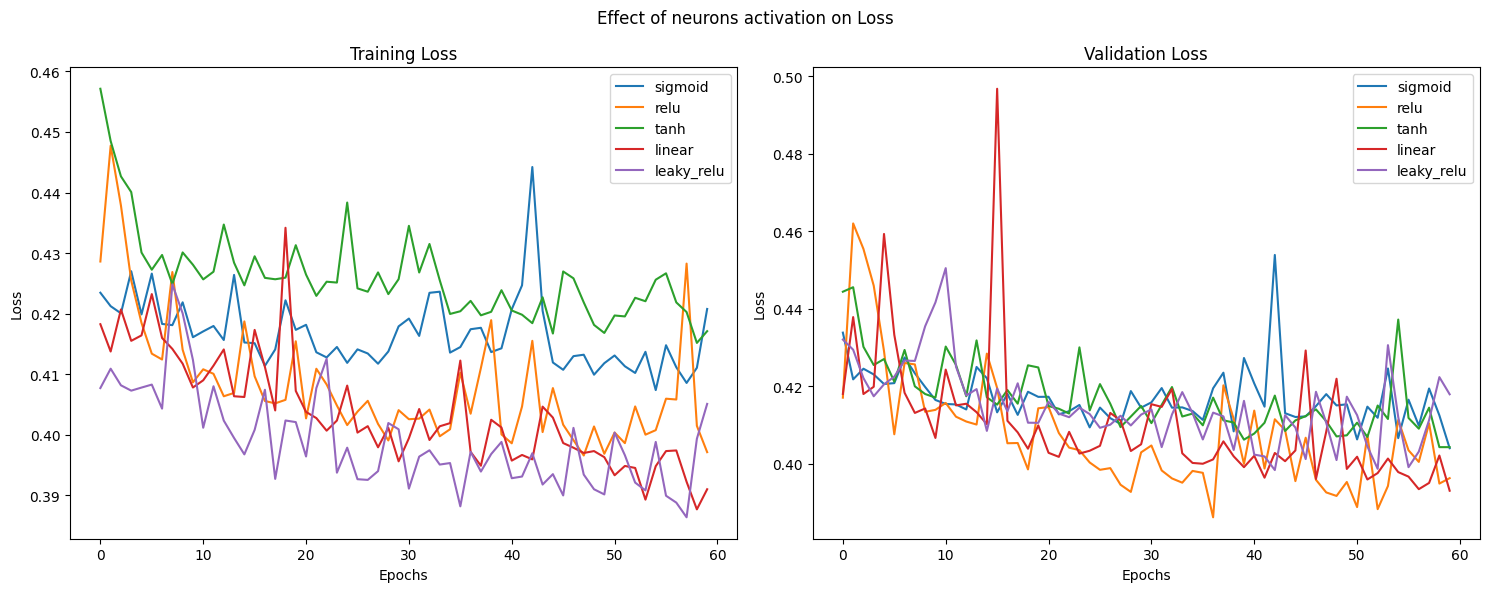

In [29]:
from_ =  0

plt.figure(figsize=(15, 6))

for i, history in enumerate(histories_activations[from_:]):
    plt.subplot(1,2, 1)
    plt.plot(history.history['loss'], label=f'{activations[i+from_]}')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1,2, 2)
    plt.plot(history.history['val_loss'] , label=f'{activations[i+from_]}')
    plt.title('Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
plt.suptitle('Effect of neurons activation on Loss')
plt.tight_layout()
plt.show()

In [30]:
data = {}
for i, model in enumerate(models_activations):
    y_pred_probs = model.predict(X_test, verbose = 0).flatten()
    y_pred = (y_pred_probs > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_probs)
    data[activations[i]] = {
        'accuracy': acc,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'auc': auc
    }
df_metrics_act = pd.DataFrame(data).T
df_metrics_act = df_metrics_act.sort_index()
df_metrics_act

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,accuracy,recall,precision,f1,auc
leaky_relu,0.611111,0.000000,0.000000,0.000000,0.404416
linear,0.388889,1.000000,0.388889,0.560000,0.586234
relu,0.377778,0.685714,0.347826,0.461538,0.304935
sigmoid,0.388889,1.000000,0.388889,0.560000,0.463896
tanh,0.366667,0.400000,0.280000,0.329412,0.337922


En este escenario, la activaciómn sigmoide parece ser aquella que da mejores resultados, las funcion leaky_relu genera un modelo trivial que refleja metricas muy pobres para recall y precision

### c. Adicione una capa oculta adicional y pruebe varias configuraciones. Muestre y discuta los resultados.

In [31]:
def build_model(lr=0.01,num_neurons_1=14,activation_1='sigmoid',num_neurons_2=14,activation_2='sigmoid'):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(num_neurons_1, activation=activation_1),
        tf.keras.layers.Dense(num_neurons_2, activation=activation_2),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy'
    )
    return model

In [32]:
n_n_1 = [i for i in range(22, 25)]
n_n_2 = [i for i in range(22, 25)]
act_1 = ['relu', 'tanh']
act_2 = ['sigmoid', 'relu']
lr_ = [0.01, 0.001]

print(f'Number of models to train: {len(n_n_1) * len(n_n_2) * len(act_1) * len(act_2) * len(lr_)}')

Number of models to train: 72


In [33]:
options = list(product(lr_, n_n_1, n_n_2, act_1, act_2))
test_models = [None] * len(options)
test_histories = [None] * len(options)
i = 1
for lr, n1, n2, a1, a2 in options:
    print(f'Training model {i:>2}/{len(options)} with lr: {lr}, n1: {n1}, n2: {n2}, a1: {a1}, a2: {a2}')
    model = build_model(lr=lr, num_neurons_1=n1, activation_1=a1, num_neurons_2=n2, activation_2=a2)
    test_histories[i-1] = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=32,
        verbose=0
    )
    test_models[i-1] = model
    i+=1

Training model  1/72 with lr: 0.01, n1: 22, n2: 22, a1: relu, a2: sigmoid
Training model  2/72 with lr: 0.01, n1: 22, n2: 22, a1: relu, a2: relu
Training model  3/72 with lr: 0.01, n1: 22, n2: 22, a1: tanh, a2: sigmoid
Training model  4/72 with lr: 0.01, n1: 22, n2: 22, a1: tanh, a2: relu
Training model  5/72 with lr: 0.01, n1: 22, n2: 23, a1: relu, a2: sigmoid
Training model  6/72 with lr: 0.01, n1: 22, n2: 23, a1: relu, a2: relu
Training model  7/72 with lr: 0.01, n1: 22, n2: 23, a1: tanh, a2: sigmoid
Training model  8/72 with lr: 0.01, n1: 22, n2: 23, a1: tanh, a2: relu
Training model  9/72 with lr: 0.01, n1: 22, n2: 24, a1: relu, a2: sigmoid
Training model 10/72 with lr: 0.01, n1: 22, n2: 24, a1: relu, a2: relu
Training model 11/72 with lr: 0.01, n1: 22, n2: 24, a1: tanh, a2: sigmoid
Training model 12/72 with lr: 0.01, n1: 22, n2: 24, a1: tanh, a2: relu
Training model 13/72 with lr: 0.01, n1: 23, n2: 22, a1: relu, a2: sigmoid
Training model 14/72 with lr: 0.01, n1: 23, n2: 22, a1: 

In [34]:
data = {}
for option, model in zip(options,test_models):
    y_pred_probs = model.predict(X_test, verbose = 0).flatten()
    y_pred = (y_pred_probs > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_probs)
    data[option] = {
        'accuracy': acc,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'auc': auc
    }
df_metrics_tests = pd.DataFrame(data).T
df_metrics_tests = df_metrics_tests.sort_index()
df_metrics_tests

accuracy    recall  precision        f1       auc
0.001 22 22 relu relu     0.777778  0.628571   0.758621  0.687500  0.824935
                 sigmoid  0.800000  0.657143   0.793103  0.718750  0.821818
            tanh relu     0.777778  0.714286   0.714286  0.714286  0.833766
                 sigmoid  0.800000  0.657143   0.793103  0.718750  0.818182
         23 relu relu     0.744444  0.514286   0.750000  0.610169  0.792208
...                            ...       ...        ...       ...       ...
0.010 24 23 tanh sigmoid  0.766667  0.542857   0.791667  0.644068  0.810909
         24 relu relu     0.811111  0.742857   0.764706  0.753623  0.795844
                 sigmoid  0.788889  0.742857   0.722222  0.732394  0.828052
            tanh relu     0.811111  0.714286   0.781250  0.746269  0.816104
                 sigmoid  0.766667  0.542857   0.791667  0.644068  0.810390

[72 rows x 5 columns]

In [35]:
best_models_test_index = df_metrics_tests.idxmax()
metrics = df_metrics_tests.columns
for metric, best_metric_model in zip(metrics, best_models_test_index):
    print(f'Best {metric} at {best_metric_model}: {df_metrics_tests[metric].max():.4f}')

Best accuracy at (0.001, 23, 23, 'tanh', 'sigmoid'): 0.8222
Best recall at (0.001, 24, 23, 'relu', 'relu'): 0.7714
Best precision at (0.001, 23, 24, 'tanh', 'relu'): 0.8462
Best f1 at (0.001, 24, 23, 'relu', 'relu'): 0.7606
Best auc at (0.01, 23, 24, 'relu', 'relu'): 0.8483


In [36]:
value = mode([options.index(k) for k in best_models_test_index.tolist()])
best_model_tests = test_models[value]
best_model_history = test_histories[value]

Vamos a entrenar por mas epocas este modelo

In [37]:
new_history = best_model_tests.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=340,
    batch_size=32,
    verbose=1
)

Epoch 1/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4278 - val_loss: 0.4789
Epoch 2/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3965 - val_loss: 0.4568
Epoch 3/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4071 - val_loss: 0.4724
Epoch 4/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4162 - val_loss: 0.4757
Epoch 5/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4232 - val_loss: 0.4960
Epoch 6/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4429 - val_loss: 0.4688
Epoch 7/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4202 - val_loss: 0.4699
Epoch 8/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4302 - val_loss: 0.4988
Epoch 9/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4153 - val_loss: 0.4653
Epoch 10/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3952 - val_loss: 0.4666
Epoch 11/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4308 - val_loss: 0.4824
Epoch 12/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4

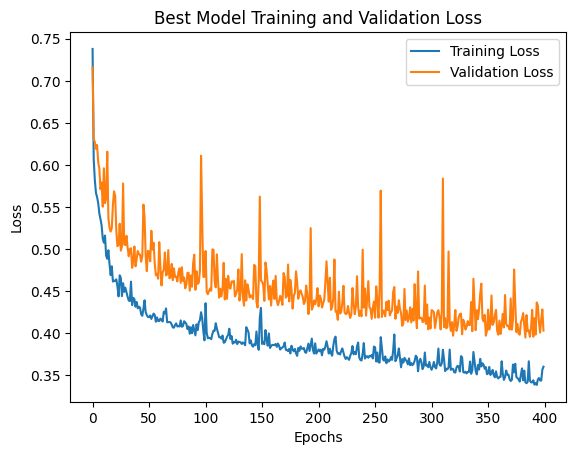

In [38]:
plt.plot(best_model_history.history['loss'] + new_history.history['loss'], label='Training Loss')
plt.plot(best_model_history.history['val_loss'] + new_history.history['val_loss'], label='Validation Loss')
plt.title('Best Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### d. Haga una comparación detallada con diferentes métricas de desempeño entre el modelo del anterior punto y el mejor modelo encontrado en este punto.

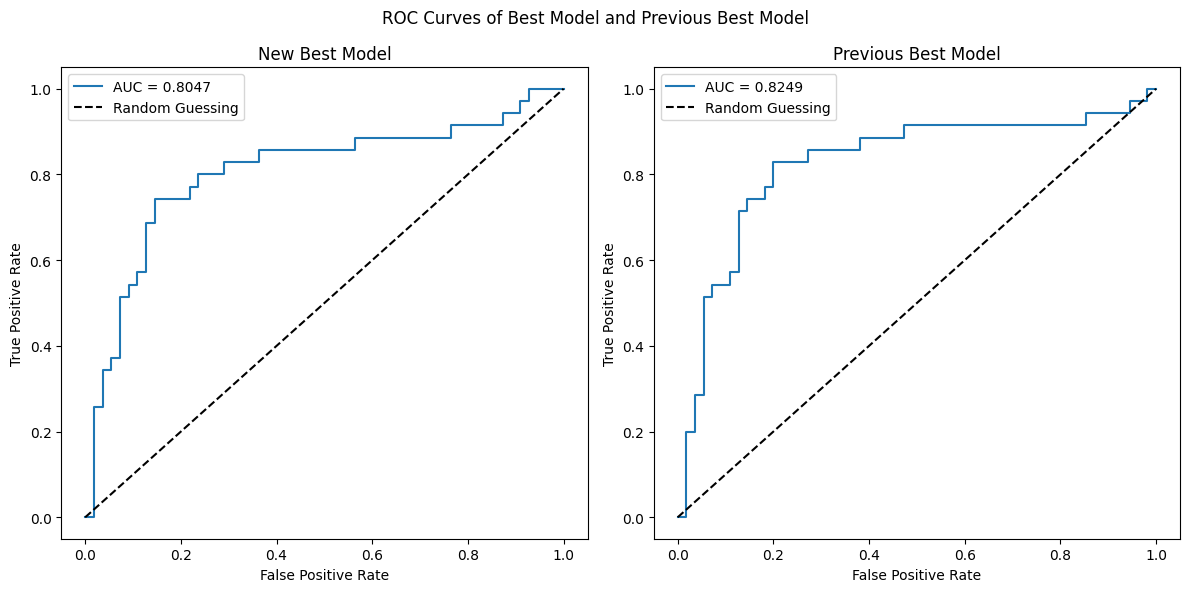

In [39]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2, 1)
preds = best_model_tests.predict(X_test, verbose=0).flatten()
fpr, tpr, thresholds = roc_curve(y_test, preds)
auc = roc_auc_score(y_test, preds)
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('New Best Model')
plt.legend()
plt.subplot(1,2, 2)
preds = best_model.predict(X_test, verbose=0).flatten()
fpr, tpr, thresholds = roc_curve(y_test, preds)
auc = roc_auc_score(y_test, preds)
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Previous Best Model')
plt.legend()
plt.suptitle('ROC Curves of Best Model and Previous Best Model')
plt.tight_layout()
plt.show()


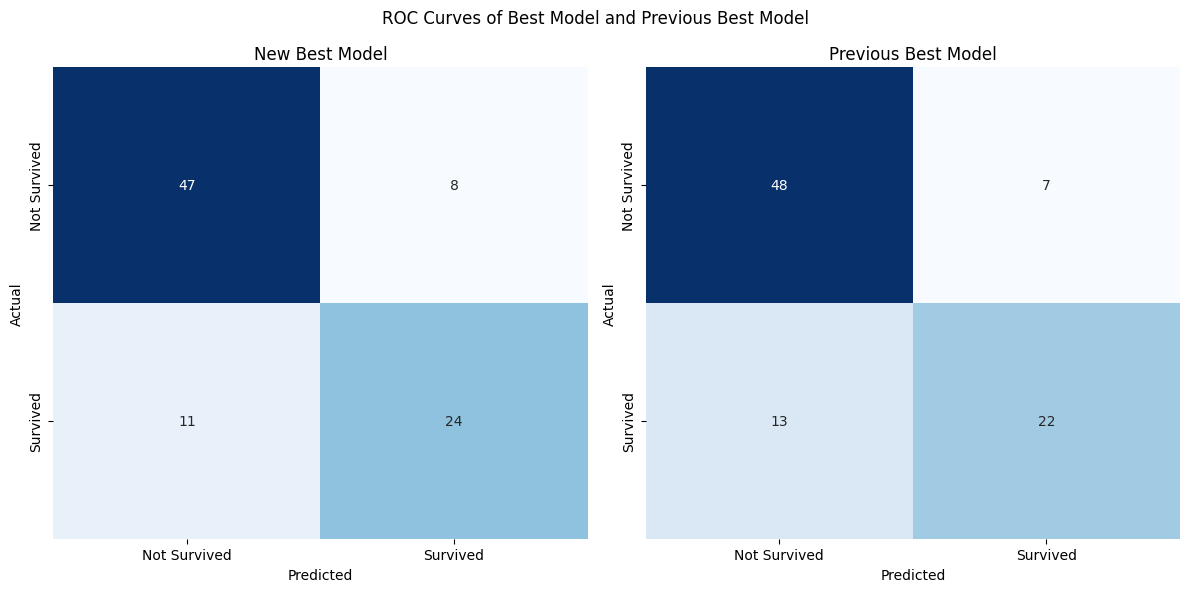

In [40]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2, 1)
preds = best_model_tests.predict(X_test, verbose=0).flatten()
cmp = confusion_matrix(y_test, (preds > 0.5).astype(int))
sns.heatmap(cmp, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'], cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('New Best Model')
plt.subplot(1,2, 2)
preds = best_model.predict(X_test, verbose=0).flatten()
cmp = confusion_matrix(y_test, (preds > 0.5).astype(int))
sns.heatmap(cmp, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'], cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Previous Best Model')
plt.title('Previous Best Model')
plt.suptitle('ROC Curves of Best Model and Previous Best Model')
plt.tight_layout()
plt.show()


In [41]:
print(f'Report for New Best Model:\n\n{classification_report(y_test, (best_model_tests.predict(X_test, verbose=0).flatten() > 0.5).astype(int))}')
print(f'\nReport for Previous Best Model:\n\n{classification_report(y_test, (best_model.predict(X_test, verbose=0).flatten() > 0.5).astype(int))}')

Report for New Best Model:

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        55
           1       0.75      0.69      0.72        35

    accuracy                           0.79        90
   macro avg       0.78      0.77      0.77        90
weighted avg       0.79      0.79      0.79        90


Report for Previous Best Model:

              precision    recall  f1-score   support

           0       0.79      0.87      0.83        55
           1       0.76      0.63      0.69        35

    accuracy                           0.78        90
   macro avg       0.77      0.75      0.76        90
weighted avg       0.78      0.78      0.77        90

